In [1]:
!pip install torchinfo # do funkcji summary

In [2]:
import numpy as np
import torch
from scipy.signal import convolve2d
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary

### Jak zrobić zadanie

Notebook składa się z 4 zadań, jednak **najważniejsze są zadania 3 i 4**, bo dotyczą stricte własnej implementacji sieci konwolucyjnej. W poszczególnych sekcjach znajdują się opisy które powinny wystarczyć do zrozumienia i implementacji, ale poniżej zamieszczone są źródła do dalszej nauki.

Zbiorem danych będzie *FashionMNIST* lub *CIFAR10* (w zależności od waszej preferencji).

Źródła
- https://visionbook.mit.edu/convolutional_neural_nets.html -> na pograniczu CV i CNN
- https://engineering.purdue.edu/DeepLearn/pdf-kak/DemystifyConvo.pdf -> przydatne do zadania z konwolucją
- https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks#layer -> wizualizacje
- https://guandi1995.github.io/Padding/ -> objaśnienie paddingu
- https://cs231n.github.io/convolutional-networks/ -> kurs od stanford
- warstwy w PyTorch: [Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [MaxPool2d
](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html#torch.nn.MaxPool2d), [BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html#torch.nn.BatchNorm2d), [Dropout2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout2d.html#torch.nn.Dropout2d)


### 0. Po co nam coś więcej niż MLP?

Na poprzedniej liście spłaszczaliśmy obrazki, aby móc je przepuścić przez sieć FNN, jednak taki preprocessing do formy tabelarycznej gubi istotne informacje. Po pierwsze, piksele blisko siebie w oryginalnym obrazie mogą znaleźć się daleko od siebie, dodatkowo wszystkie piksele będą "wymieniać" się sygnałami z wszystkimi innymi pikselami. Jest to mechanizm dosyć nieefektywny (w szarym obrazku o rozmiarze 128x128 mamy na wejściu już 16 384 cech!) i tu na pomoc przychodzą konwolucje.

### 1. Konwolucja

Podstawową operację konwolucji jest lepiej sobie zobrazować (pun intended) na podstawie jednego, oczywistego przykładu. Załóżmy, że mamy obraz binarny (czyli składający się z 0 i 1). Jest to typowa reprezentacja maski w zadaniu segmentacji - 1 oznacza, że na danym pikselu jest interesujący nas obiekt, a 0 to tło.

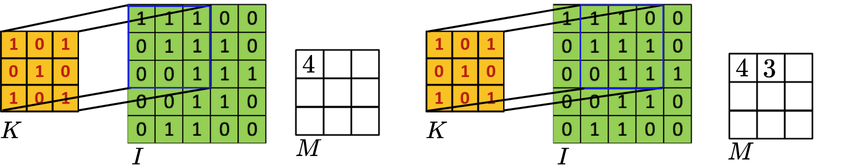

Wyjaśnienie symboli na obrazku
- $I$ - obrazek wejściowy
- $K$ - filtr (kernel) o wymiarze 3x3
- $M$ - wyjściowa mapa cech

Wynik przesuwania się filtra po wejściowej mapie można opisać wzorem

$$(K ⋆ I)(i, j) = \sum_{a=0}^{H_k-1}\sum_{b=0}^{W_k-1} K(a, b)I(i + a, j + b)$$

opisuje to jaki będzie wynik w pikselu o współrzędnych (i, j) w wynikowej mapie $M$. $H_k$ i $W_k$ oznaczają odpowiednio wysokość i szerokość filtra - często rozważamy kwadratowe rozmiary, $H_k$ = $W_k$.


(Tak naprawdę wzór wyżej opisuje korelację wzajemną - *cross-correlation*, ponieważ matematyczna operacja konwolucji dałaby wynik obrócony o 180 stopni)

Taka prosta formulacja nie uwzględnia faktu, że obrazki (zwykle) zawierają kanał koloru RGB. W takim razie filtr $K$ ma teraz możliwe współrzędne $K_{a,b,d}$. Wiemy już z poprzednich list, że budująć sieć neuronową chcemy zwiększyć liczbę ukrytych wymiarów. Dlatego też, aby zwiększyć liczbę kanałów z 3 (rgb) na $Q_k$, nasz filtr musi mieć 4 wymiary, więc indeksować się jako $K_{a,b,d,q}$. To oznacza, że mamy $Q_k$ pojedynczych filtrów, które będą przesuwać się po wejściowym obrazku. Ostatecznie konwolucja będzie mieć postać

$$M_{i,j,q} = \sum_{a=0}^{H_k-1}\sum_{b=0}^{W_k-1}\sum_{d=0}^{D_I-1}K(a, b, d, q)I(i + a, j + b, d)$$

Wynikowy rozmiar takiej mapy nie jest domyślnie równy wejściowemu obrazkowi (lub mapie). Wynika to z tego, że musimy wybrać tylko te "kawałki" obrazka, które w pełni mieszczą się w filtrze (później powiemy o paddingu). Zakładając, że obrazki są mają wymiar $H_I \times W_I \times D_I$, kernel $H_k \times W_k \times D_I \times Q_k$ to wynikowy rozmiar ma postać $$(H_I - H_k + 1) \times (W_I - W_k + 1) \times Q_k$$

Przesuwając kolejno filtr o jedną pozycję (jak dalej się dowiemy, krok jaki wykonuje filtr odnosi się do parametru *stride*) obliczamy wynikową mapę. Wartości w mapie $W$ nie są zwykle z góry znane (tym bardziej nie są binarne jak w prostym przykładzie wyżej), ale wyuczane w procesie trenowania sieci.


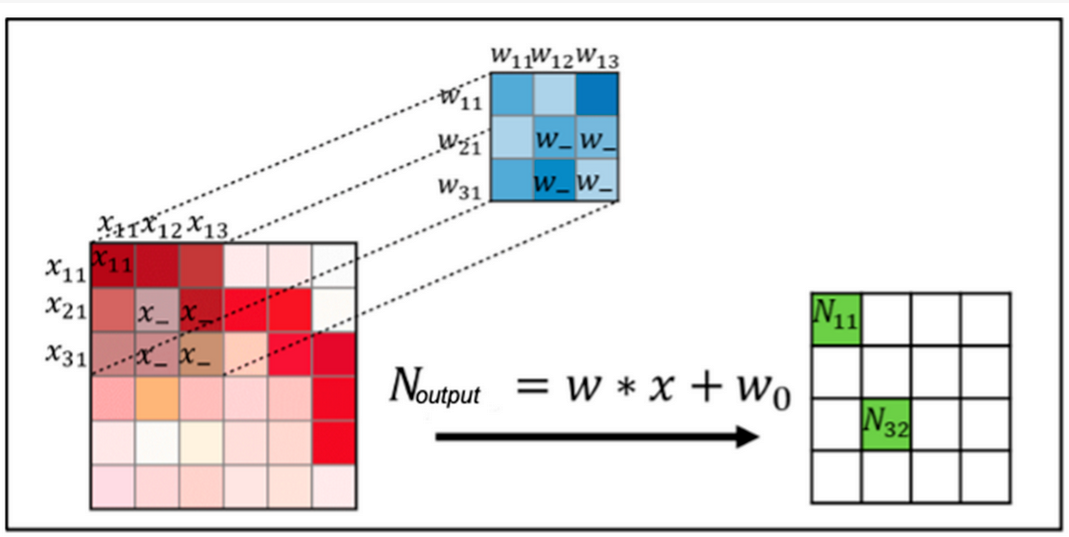

Polecam zajrzeć tutaj po interaktywną wizualizację https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks

### Zadanie 1
Bazując na opisie wyżej i wiarygodnych źródłach, napisz własną implementację operacji konwolucji. Może ona opierać się na macierzach NumPy lub PyTorch. Wykorzystaj poniższą linijkę z testami, aby sprawdzić swoje rozwiązanie.

Ekstra: pomyśl, czy dałoby się zapisać taką operację czysto w sposób macierzowy, pozbywając się pętli (lub chociaż ograniczając ich liczbę).

*Ekstra: pomyśl o dodaniu paddingu (może być to wartość 0), aby mapa wyjściowa była równa rozmiarowo wejściu (wtedy też musisz zmienić padding w testach).

In [ ]:
import torch.nn.functional as F

def convolution(X, K, q: int, padding = 0):
  '''
  Wykonuje operację konwolucji na wejściowym obrazie *X* oraz filtrze *K*. Zwraca wynikową mapę.
  Args:
    X: numpy / torch tensor o wymiarach (h, w, d)
    K: numpy / torch tensor o wymiarach (k, k, d, q)
    q: liczba filtrów
  Wyjście:
    out: wymiary (h-k+p, w-k+p, q)
  '''
  X = F.pad(input=X, pad=(0, 0, padding, padding, padding, padding), mode='constant', value=0)

  Hi, Wi, D = X.shape
  Hk, Wk, _, q = K.shape
  Ht = Hi-Hk+1
  Wt = Wi-Wk+1
  out = torch.zeros(Ht, Wt, q)

  for g in range(q):
    for i in range(Ht):
      for j in range(Wt):
        X_p = X[i : i+Hk,  j : j+Wk]
        O = X_p * K[:,:,:,g]
        out[i,j,g] = O.sum()

  return out

#### Przypadki testowe
Nie musisz nic tutaj modyfikować z wyjątkiem gdy używasz NumPy (w kodzie są zaznaczone linijki, które trzeba odkomentować)

In [ ]:
def generate_deterministic_tensor(shape, mod_val=5, offset=0):
    count = 1
    for s in shape:
        count *= s
    # Tworzymy sekwencję 0, 1, 2... i bierzemy modulo
    data = torch.arange(count).float() % mod_val + offset
    return data.reshape(shape)

def torch_2_numpy(pt):
  return pt.detach().numpy()

def run_pytorch_test(case_name, img_hwc, kernel_hwcn, padding=0):
    image_hwc = generate_deterministic_tensor(img_hwc, mod_val=5)
    kernel_hwcn = generate_deterministic_tensor(kernel_hwcn, mod_val=3, offset=-1)

    print(f"Input shape (H,W,C): {tuple(image_hwc.shape)}")
    print(f"Kernel shape (H,W,Cin,Cout): {tuple(kernel_hwcn.shape)}")

    # Dodanie wymiaru batcha
    input_tensor = image_hwc.permute(2, 0, 1).unsqueeze(0)
    weights = kernel_hwcn.permute(3, 2, 0, 1)
    output_tensor = F.conv2d(input_tensor, weights, stride=1, padding=padding)
    output_hwc = output_tensor.squeeze(0).permute(1, 2, 0)

    # ODKOMENTUJ JEŚLI twoim inputem jest wielowymiarowa macierz NumPy
    # image_hwc = torch_2_numpy(image_hwc)
    # kernel_hwcn = torch_2_numpy(kernel_hwcn)

    my_output = convolution(image_hwc, kernel_hwcn, kernel_hwcn.shape[-1], padding=padding)
    if isinstance(my_output, np.ndarray):
        my_output = torch.from_numpy(my_output)

    my_output = my_output.to(torch.float64)
    output_hwc = output_hwc.to(torch.float64) # do samego typu żeby nie było błędu

    try:
      torch.testing.assert_close(my_output, output_hwc, rtol=1e-05, atol=1e-08)
      print(f"Output shape with padding: {my_output.shape}")
      print(f"Test zaliczony")
    except AssertionError as e:
      print(f"Test niezaliczony: {e}")
    print(f"Output shape (H,W,C): {tuple(output_hwc.shape)}")

# --- URUCHOMIENIE PRZYPADKÓW ---

# Przypadek 1: Mały
run_pytorch_test("PRZYPADEK 1", (6, 6, 3), (3, 3, 3, 5), 2)

# Przypadek 2: Średni
run_pytorch_test("PRZYPADEK 2", (12, 12, 3), (3, 3, 3, 5))

# Przypadek 3: Projekcja 1x1
run_pytorch_test("PRZYPADEK 3", (24, 24, 3), (1, 1, 3, 10))

Input shape (H,W,C): (6, 6, 3)
Kernel shape (H,W,Cin,Cout): (3, 3, 3, 5)
Output shape with padding: torch.Size([8, 8, 5])
Test zaliczony
Output shape (H,W,C): (8, 8, 5)
Input shape (H,W,C): (12, 12, 3)
Kernel shape (H,W,Cin,Cout): (3, 3, 3, 5)
Output shape with padding: torch.Size([10, 10, 5])
Test zaliczony
Output shape (H,W,C): (10, 10, 5)
Input shape (H,W,C): (24, 24, 3)
Kernel shape (H,W,Cin,Cout): (1, 1, 3, 10)
Output shape with padding: torch.Size([24, 24, 10])
Test zaliczony
Output shape (H,W,C): (24, 24, 10)


### 2. Porównanie konwolucji i sieci w pełni połączonej

| Cecha | Konwolucja (CNN) | Sieć w pełni połączona (FNN / Dense) |
| :--- | :--- | :--- |
| **1. Wagi/Parametry** | **Współdzielone (Parameter Sharing)**<br>Ten sam zestaw wag (filtr) jest używany do skanowania całego obrazu | **Indywidualne**<br>Każde połączenie ma własną wagę przypisaną do konkretnego piksela/pozycji na wejściu |
| **2. Zasięg działania** | **Lokalny**<br>Operacja dotyczy tylko małego wycinka (okna) wokół aktualnie przetwarzanego punktu | **Globalny**<br>Każdy neuron w warstwie ukrytej "widzi" i jest połączony ze wszystkimi pikselami obrazu wejściowego |
| **3. Przesunięcie obiektu** | **Ekwiwariancja na translację**<br>Jeśli obiekt (np. kot) przesunie się na obrazie, sieć nadal go wykryje (tylko w innym miejscu mapy cech) | **Wrażliwość na pozycję**<br>Sieć musi "nauczyć się" wyglądu kota w każdym możliwym położeniu osobno, traktując je jako zupełnie nowe wzorce |
| **Efektywność** | Mniejsza liczba parametrów (dzięki współdzieleniu wag), szybsze uczenie obrazów | Ogromna liczba parametrów przy dużych obrazach, wysokie ryzyko przeuczenia |

### 3. Pole recepcyjne

Po angielsku *receptive field* odnosi się do wszystkich możliwych miejsc na obrazku, jak i na poprzednich mapach, które mogą wpływać na wynik w aktualnie rozważanym elemencie. Lepiej to obrazuje załączony schemat, gdzie widzimy jak element po środku tak naprawdę posiada informacje z poprzednich warstw. Jest to główna koncepcja w kontekście projektowania architektur konwolucyjnych sieci neuronowych, gdzie głębsze warstwy uczą się bardziej skomplikowanych struktur bazując na prymitywnych kształtach zidentyfikowanych na niższych warstwach.

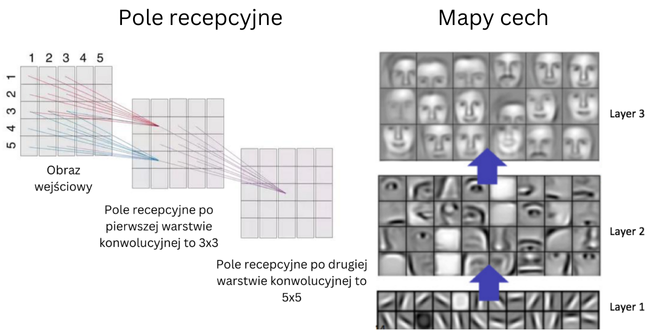

### 4. Operacja Poolingu

Aby jeszcze bardziej zmniejszyć rozmiar wynikowej mapy (tj. jej szerokość i wysokość) stosuje się operacje *max* lub *avg* pooling. Działają one w ten sposób, że na każdym rozłącznym kawałku wejściowego obrazka/mapy wykonujemy pewną redukcję do jednej wartości wyjściowej. Przypomina to operację konwolucji, natomiast nie mamy tutaj żadnych wag kernela, tylko z góry deterministyczną operację. Zastosowanie poolingu na kawałkach $2 \times 2$ zmniejsza wejściowy tensor dwukrotnie (dla $3 \times 3 $ zmniejszy trzykrotnie, i tak dalej). Zdecydowanie bardziej popularny jest **max pooling**, ponieważ przypomina wyciąganie tej najbardziej istotnej informacji z obrazka.

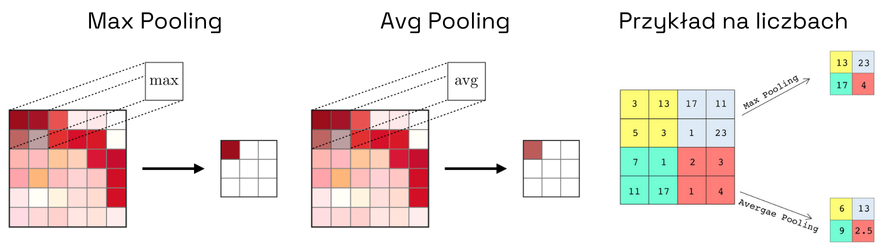

$$M(i, j) = \max_{(a, b) \in 𝒩} I(a, b) ← \text{max pooling} $$  
$$M(i, j) = \frac{1}{|𝒩|} \sum_{(a, b) \in 𝒩} I(a, b)  ← \text{avg pooling}$$

gdzie
- $I$ - wejściowy obrazek lub mapa
- $M$ - wyjściowa mapa
- $𝒩$ - fancy matematyczny znaczek na określenie sąsiedztwa, a w praktyce to zbiór wszystkich pozycji na wejściu $(a, b)$ które są aktualnie w rozważanym obszarze $n \times n$

#### Global Average Pooling

Ważną operacją bezpośrednio przydatną gdy będziemy implementować sieć CNN jest ekstremalna wersja poolingu, która przyjmuje mapę o wymiarze $H \times W \times C$ i zwraca wektor o długości $C$ (Tj. dla każdego kanału $c$ oblicza średnią po $H$ i $W$). Zwykle ta warstwa stanowi pomost między częścią konwolucyjną sieci a częścią w pełni połączoną (FFN).

### 5. Warstwa konwolucji w PyTorch
Zanim zaczniemy budować sieć składającą się z wielu warstw konwolucji, to warto zrozumieć jakie przyjmuje ona (najistotniejsze) parametry

```
class torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)
```

- in_channels - liczba filtrów w wejściowej mapie/obrazku. Będzie to 3 dla obrazu RGB, a dla pośrednich map to będzie zależeć od liczby *out_channels* poprzedniej warstwy
- out_channels - liczba filtrów wyjściowych mapy (a jednocześnie liczba filtrów wejściowych do kolejnej warstwy konwolucyjnej)
- kernel_size - tuple (wysokość, szerokość) lub skalar dla kwadratowego filtra, od tej wielkości zależy też wysokość i szerokość wynikowej mapy
- stride - domyślnie 1, określa o ile pikseli przesuwamy się filtrem w każdym kolejnym kroku. Wybranie wartości > 1 ma podobny wpływ jak zastosowanie poolingu
- padding - domyślnie brak, określa jaka jest szerokość ramki, która jest dodawana do wejściowej mapy. Jest to przydatne kiedy chcemy, żeby wielkość wynikowej mapy była równa mapie wejściowej - wtedy podajemy jako wartość 'same' (tylko dla $stride = 1$)
- dilation - domyślnie 1, określa w obrębie samego filtra jaki jest odstęp między pikselami mapy wejściowej
- bias - oznacza to samo co dla warstwy liniowej, może być konieczne ustawienie na *False*

`kernel_size`, `stride`, `padding` i `dilation` mogą być typu `int` dla kwadratowych obszarów, lub `tuple` do określenia oddzielnie wysokości i szerokości

Wzór na wysokość ($H$) i szerokość ($W$) wyjściową ma postać
$$H_{out} = ⌊ \frac{H_{in} + 2 \times padding[0] - dilation[0] \times (kernel\_size[0] - 1) - 1}{stride[0]} + 1⌋$$

$$W_{out} = ⌊ \frac{W_{in} + 2 \times padding[1] - dilation[1] \times (kernel\_size[1] - 1) - 1}{stride[1]} + 1⌋$$

(symbol "podłogi" $⌊$, $⌋$ oznacza zaokrąglenie w dół do liczby całkowitej)

dla kwadratowego wejścia i filtrów upraszcza się to do $H_{out} = W_{out}$



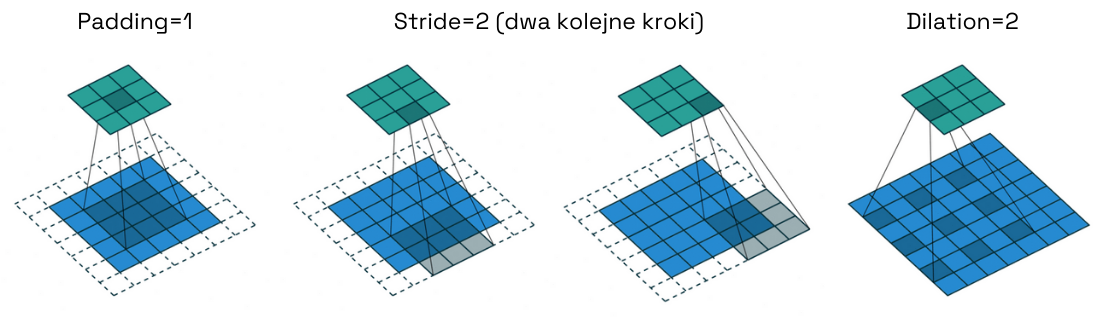

### Zadanie 2
Na podstawie wyżej wyjaśnionych argumentów i wzorów uzupełnij poniżej brakujące wartości. Nie musisz nad tym spędziać nie wiadomo ile czasu, ale warto nabrać intuicji które parametry musisz zmienić i jakie powinny być wartości by uzyskać zamierzoną wyjściową wielkość.

**Uwaga** zgodnie z konwencją Pytorcha, kolejność wymiarów po kolei to ($B$, $D$, $H$, $W$), tak więc wymiar kanału znajduje się nie na końcu, lecz na początku każdego obrazka/mapy. $B$ to batch size równy 1 tutaj.

In [ ]:
def validate_layer(case_name, layer, input_shape, expected_shape):
    print(f"--- {case_name} ---")
    print(f"Input: {input_shape}")

    # Tworzymy losowy tensor z batch=1
    x = torch.randn(1, *input_shape)

    try:
        y = layer(x)
        out_shape = tuple(y.shape)[1:] # bez batch

        print(f"Oczekiwany kształt: {expected_shape}")
        print(f"Twój kształt:       {out_shape}")

        if out_shape == expected_shape:
            print("OK. \n")
        else:
            print("Błąd: Kształty się nie zgadzają.\n")

    except Exception as e:
        print(f"Jakiś błąd: {e}\n")

# -------- TEST CASES ---------------

# PRZYPADEK 1: Agresywna redukcja (styl pierwszej warstwy AlexNet)
# Wejście: 224x224 (obraz)
# Wyjście: 55x55
# Wymagane: Użyj Padding=2. Resztę dobierz.
# Wskazówka: Kernel jest duży (>7), a krok (stride) też jest spory (>2).
case_1 = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    padding=2,
    dilation=1,
    # --- DO UZUPEŁNIENIA ---
    kernel_size=10,  # <-- zmień to
    stride=4        # <-- zmień to
)


# Test 1
validate_layer("PRZYPADEK 1: Redukcja 224 -> 55", case_1,
                input_shape=(3, 224, 224),
                expected_shape=(64, 55, 55))

# PRZYPADEK 2: Asymetryczna konwolucja
# Wejście: 32x32
# Wyjście: 30x16
# Wymagane: Padding=0.
# Wskazówka: Wysokość (32->30) maleje wolno, Szerokość (32->16) maleje szybko.
# Użyj krotki (tuple) dla kernel_size i stride, np. (h, w).
case_2 = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    padding=0,
    dilation=1,
    # --- DO UZUPEŁNIENIA ---
    kernel_size=(3, 2), # <-- zmień to
    stride=(1, 2)       # <-- zmień to
)

# Test 2
validate_layer("PRZYPADEK 2: Prostokątne okna 32 -> 30x16", case_2,
                input_shape=(1, 32, 32),
                expected_shape=(1, 30, 16))


# PRZYPADEK 3: "Dziurawy" Kernel (Dilated Convolution)
# Wejście: 50x50
# Wyjście: 46x46
# Wymagane: Stride=1, Padding=0. Kernel ma rozmiar 3x3.
# Zastanów się jak to możliwe, że kernel (3, 3) zmniejsza wielkość aż o 4 piksele?
case_3 = nn.Conv2d(
    in_channels=16,
    out_channels=16,
    stride=1,
    padding=0,
    kernel_size=3,
    # --- DO UZUPEŁNIENIA ---
    dilation=2  # <-- zmień to
)


# Test 3
validate_layer("PRZYPADEK 3: Dylatacja 50 -> 46", case_3,
                input_shape=(16, 50, 50),
                expected_shape=(16, 46, 46))

--- PRZYPADEK 1: Redukcja 224 -> 55 ---
Input: (3, 224, 224)
Oczekiwany kształt: (64, 55, 55)
Twój kształt:       (64, 55, 55)
OK. 

--- PRZYPADEK 2: Prostokątne okna 32 -> 30x16 ---
Input: (1, 32, 32)
Oczekiwany kształt: (1, 30, 16)
Twój kształt:       (1, 30, 16)
OK. 

--- PRZYPADEK 3: Dylatacja 50 -> 46 ---
Input: (16, 50, 50)
Oczekiwany kształt: (16, 46, 46)
Twój kształt:       (16, 46, 46)
OK. 



### 6. Architektura sieci konwolucyjnej

Głębokie sieci konwolucyjne składają się z warstw konwolucyjnych przeplatanych funkcjami aktywacji (zwykle ReLU), operacjami Poolingu, oraz odpowiednikami w 2D Batch Normalization i Dropout (niekoniecznie w tej kolejności). Wraz z kolejnymi warstwami powinna rosnąć liczba filtrów (np. 16 -> 32 -> 64 -> 128 itp.) i zmniejszać się wielkość każdej wynikowej mapy (filtry mają zwykle rozmiar 3x3).

Po serii takich warstw musimy znowu wrócić do w pełni połączonych warstw, z tego powodu stosujemy Global Average Pooling. Typowo taka architektura posłuży do zadania klasyfikacji.  



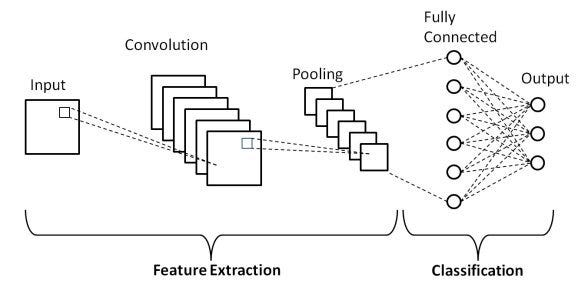

### Zadanie 3

**Zaimplementuj** i **wytrenuj** sieć konwolucyjną do zadania klasyfikacji dla zbioru FashionMNIST lub CIFAR10 (dowolność wyboru) która będzie zawierała następujące elementy
- co najmniej 2 bloki składające się z warstw konwolucyjnych i funkcji aktywacji
- sieci w pełni połączonej (minimalna głębokość to 1) służącej jako klasyfikator (powinno to być łatwe po poprzedniej liście)
- na tym etapie użyj [Flatten](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.flatten.Flatten.html) do spłaszczenia wymiarów $(B, C, H, W) → (B, C * H * W)$ dla wejścia do warswty liniowej

posłuży ona jako baseline do dalszych eksperymentów. Jeśli dysponujesz siecią FNN z poprzedniej listy, to możesz też odnieść się do jej wyników (nie musisz jej tutaj kopiować i na nowo trenować).

Przebieg trenowania dla sieci konwolucyjnej jest praktycznie taki sam jak do sieci z poprzedniego zadania, tylko że nie spłaszczamy obrazków na wejściu (m. in).

Przykładowy kod do pobrania danych (można go modyfikować):

```python
from torchvision import datasets

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # lub użyjcie innej normalizacji jeśli uznacie za prawidłowe
  ])

trainset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
```
**Zwizualizuj** krzywe uczenia tak jak na poprzednich listach i odpowiednie metryki (np. *f1-score* lub *accuracy*)

In [3]:
from google.colab import drive
from torchvision import datasets, transforms

drive.mount('/content/drive')
dir = "/content/drive/MyDrive/datasets/fashion_mnist"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.FashionMNIST(
  root=dir,
  train=True,
  download=True,
  transform=transform
)

testset = datasets.FashionMNIST(
  root=dir,
  train=False,
  download=True,
  transform=transform
)

Mounted at /content/drive


In [4]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import numpy as np


BATCH_SIZE = 128
SEED = 67

train_idx, val_idx = train_test_split(
    range(len(trainset)),
    test_size = 0.1,
    random_state=SEED,
    shuffle=True
)

train_loader = DataLoader(Subset(trainset, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(Subset(trainset, val_idx), batch_size=BATCH_SIZE, num_workers=2)
test_loader = DataLoader(testset, batch_size=64)

In [5]:
import torch
import torch.nn as nn
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CNN(nn.Module):
  def __init__(self, max_pool = True, global_avg_pool = False, batch_normalization = False, dropout=0.0, use_more_layers=False):
    super().__init__()

    self.kwargs = dict(
      max_pool=max_pool,
      global_avg_pool=global_avg_pool,
      batch_normalization=batch_normalization,
      dropout=dropout,
      use_more_layers=use_more_layers
    )

    self.batch_normalization = batch_normalization
    self.use_more_layers = use_more_layers
    self.global_avg_pool = global_avg_pool

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
    self.relu1 = nn.ReLU()
    self.bn1 = nn.BatchNorm2d(16)
    self.pool1 = nn.MaxPool2d(2) if max_pool else nn.AvgPool2d(2)
    self.dropout1 = nn.Dropout(dropout)

    self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1)
    self.relu2 = nn.ReLU()
    self.bn2 = nn.BatchNorm2d(16)
    self.pool2 = nn.MaxPool2d(2) if max_pool else nn.AvgPool2d(2)
    self.dropout2 = nn.Dropout(dropout)

    self.global_pool = nn.AdaptiveAvgPool2d(1)
    self.flat = nn.Flatten()
    self.lin = nn.Linear(16, 10) if global_avg_pool else nn.Linear(16 * 7 * 7, 10)

    if self.use_more_layers:
      self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
      self.relu3 = nn.ReLU()
      self.bn3 = nn.BatchNorm2d(32)
      self.pool3 = nn.MaxPool2d(2) if max_pool else nn.AvgPool2d(2)
      self.dropout3 = nn.Dropout(dropout)

      self.lin = nn.Linear(32, 16) if global_avg_pool else nn.Linear(32 * 3 * 3, 16)
      self.lin2 = nn.Linear(16, 10)

  def forward(self, x):
    x = self.relu1(self.conv1(x))
    x = self.bn1(x) if self.batch_normalization else x
    x = self.dropout1(self.pool1(x))

    x = self.relu2(self.conv2(x))
    x = self.bn2(x) if self.batch_normalization else x
    x = self.dropout2(self.pool2(x))

    if self.use_more_layers:
      x = self.relu3(self.conv3(x))
      x = self.bn3(x) if self.batch_normalization else x
      x = self.dropout3(self.pool3(x))

    x = self.global_pool(x) if self.global_avg_pool else x
    x = self.flat(x)
    x = self.lin(x)

    if self.use_more_layers:
      x = self.lin2(x)

    return x

  def save_checkpoint(self, path):
    ckpt = {
        "model_class": "CNN",
        "model_kwargs": self.kwargs,
        "state_dict": self.state_dict()
    }
    torch.save(ckpt, path)

## Trener itp

In [6]:
# czysc historie
import pandas as pd
models = pd.DataFrame(columns=["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "val_prec", "val_rec", "val_f1", "model"])

In [7]:
import torch
import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [8]:
def accuracy(logits, targets):
  preds = torch.argmax(logits, dim=1)
  return (preds == targets).float().mean().item()

def precision(logits, targets, num_classes):
  preds = torch.argmax(logits, dim=1)
  precision_per_class = []
  for c in range(num_classes):
    tp = ((preds == c) & (targets == c)).sum().item()
    fp = ((preds == c) & (targets != c)).sum().item()
    precision_per_class.append(tp / (tp + fp) if tp+fp > 0 else 0)

  return sum(precision_per_class) / num_classes

def recall(logits, targets, num_classes):
  preds = torch.argmax(logits, dim=1)
  recall_per_class = []

  for c in range(num_classes):
    tp = ((preds == c) & (targets == c)).sum().item()
    fn = ((preds != c) & (targets == c)).sum().item()
    recall_per_class.append(tp / (tp + fn) if tp+fn > 0 else 0)

  return sum(recall_per_class) / num_classes

def f1_score(p, r, num_classes):
    return 2 * p * r / (p + r) if p+r > 0 else 0

def metrics(logits, targets, num_classes):
  acc = accuracy(logits, targets)
  p = precision(logits, targets, num_classes)
  r = recall(logits, targets, num_classes)
  f1 = f1_score(p, r, num_classes)
  return (acc, p, r, f1)


In [9]:
def evaluate_model(model, loader, criterion):
  model.eval()
  loss, acc, prec, rec, f1 = 0, 0, 0, 0, 0
  total_samples = 0

  with torch.no_grad():
    for x, y in loader:
      x, y = x.to(device), y.to(device)

      logits = model(x)
      curr_loss = criterion(logits, y)
      curr_samples = x.size(0)

      total_samples += curr_samples
      loss += curr_loss.item() * curr_samples
      curr_acc, curr_prec, curr_rec, curr_f1 = metrics(logits, y, 10)
      acc += curr_acc * curr_samples
      prec += curr_prec * curr_samples
      rec += curr_rec * curr_samples
      f1 += curr_f1 * curr_samples

  loss /= total_samples
  acc /= total_samples
  prec /= total_samples
  rec /= total_samples
  f1 /= total_samples
  return loss, acc, prec, rec, f1

In [10]:
# dla modeli dla ktorych nie zapisalem checkpointow
def load_and_save_as_checkpoint(model_kwargs, model_name):
  model = CNN(**model_kwargs).to(device)
  model.load_state_dict(torch.load(f"{dir}/{model_name}.pt", weights_only=True))
  model.eval()
  model.save_checkpoint(path=f"{dir}/{model_name}_ckpt.pt")


In [11]:
from datetime import datetime

class Trainer():
  def __init__(self, model, train_loader, val_loader, criterion, optimizer):
    self.train_loader = train_loader
    self.val_loader = val_loader
    self.criterion = criterion
    self.optimizer = optimizer
    self.model = model
    self.history = []

  def evaluate(self, epoch, train_loss, train_acc):
    self.model.eval()
    v_loss, v_acc, v_prec, v_rec, v_f1 = evaluate_model(self.model, self.val_loader, self.criterion)

    current_lr = self.optimizer.param_groups[0]["lr"]
    self.history.append([epoch, train_loss, train_acc, v_loss, v_acc, v_prec, v_rec, v_f1])
    print(f"Epoch {epoch}, LR {current_lr} | loss={train_loss:.4f}, acc={train_acc:.4f} | val_loss={v_loss:.4f}, val_acc={v_acc:.4f}, val_prec={v_prec:.4f}, val_rec={v_rec:.4f}, val_f1={v_f1:.4f}")
    return v_loss

  def validate(self, epoch, val_loss):
    if val_loss < self.best_val_loss:
        self.best_val_loss = val_loss
        self.best_val_epoch = epoch
        self.patience_counter = 0
        #torch.save(self.model.state_dict(), self.save_path)
        self.model.save_checkpoint(self.save_path)
    else:
      self.patience_counter += 1
      if self.patience_counter >= self.patience and self.patience != -1:
        print(f"Stopping. Patience counter {self.patience_counter} >= {self.patience}")
        return False
    return True

  def save_model_history(self):
    global models
    model_data = pd.DataFrame(self.history, columns=["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "val_prec", "val_rec", "val_f1"])
    model_data["model"] = self.model_name

    models = models[models["model"] != self.model_name] # usun jesli byla poprzednia historia
    models = pd.concat([models, model_data], ignore_index=True)

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    file_name = f"{dir}/all_models_data_{timestamp}.csv"
    models.to_csv(file_name, index=False)

  def train(self, model_name, epochs=50, patience = 7):
    model = self.model
    self.model_name = model_name
    self.save_path = f"{dir}/{model_name}_ckpt.pt"
    self.best_val_loss = float("inf")
    self.best_val_epoch = 0
    self.patience_counter = 0
    self.patience = patience
    self.history = []

    for e in range(epochs):
      train_loss = 0
      train_acc = 0
      total_samples = 0

      model.train()
      for x, y in train_loader: # batching
        x, y = x.to(device), y.to(device)

        self.optimizer.zero_grad()
        logits = model(x)
        loss = self.criterion(logits, y)
        loss.backward()
        self.optimizer.step()

        curr_samples = x.size(0)
        total_samples += curr_samples
        train_loss += loss.item() * curr_samples
        train_acc += accuracy(logits, y) * curr_samples

      train_loss /= total_samples
      train_acc /= total_samples

      val_loss = self.evaluate(e, train_loss, train_acc)
      if not self.validate(e, val_loss):
        break

    self.save_model_history()
    print(f"Best val loss: {self.best_val_loss} on epoch {self.best_val_epoch}")


## Bazowy model

In [ ]:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer)
trainer.train("best_model_cnn", epochs=30)

Epoch 0, LR 0.001 | loss=0.6115, acc=0.7891 | val_loss=0.4198, val_acc=0.8500, val_prec=0.8523, val_rec=0.8517, val_f1=0.8519
Epoch 1, LR 0.001 | loss=0.3778, acc=0.8670 | val_loss=0.3531, val_acc=0.8767, val_prec=0.8784, val_rec=0.8770, val_f1=0.8777
Epoch 2, LR 0.001 | loss=0.3356, acc=0.8820 | val_loss=0.3293, val_acc=0.8832, val_prec=0.8834, val_rec=0.8831, val_f1=0.8832
Epoch 3, LR 0.001 | loss=0.3115, acc=0.8897 | val_loss=0.3163, val_acc=0.8873, val_prec=0.8883, val_rec=0.8873, val_f1=0.8878
Epoch 4, LR 0.001 | loss=0.2968, acc=0.8942 | val_loss=0.3118, val_acc=0.8887, val_prec=0.8916, val_rec=0.8886, val_f1=0.8900
Epoch 5, LR 0.001 | loss=0.2826, acc=0.8996 | val_loss=0.3088, val_acc=0.8900, val_prec=0.8974, val_rec=0.8900, val_f1=0.8937
Epoch 6, LR 0.001 | loss=0.2691, acc=0.9052 | val_loss=0.3024, val_acc=0.8922, val_prec=0.8952, val_rec=0.8913, val_f1=0.8932
Epoch 7, LR 0.001 | loss=0.2610, acc=0.9069 | val_loss=0.2981, val_acc=0.8950, val_prec=0.9002, val_rec=0.8954, val_f1

/tmp/ipython-input-3487806547.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  models = pd.concat([models, model_data], ignore_index=True)


### Zadanie 4

Przeprowadź następujące eksperymenty:

- Eksperyment 1: Dodaj *Max Pooling* w odpowiednim miejscu po warstwach konwolucyjnych. Porównaj z działaniem *Average Pooling*.

- Eksperyment 2: Dodaj warstwę *Global Average Pooling* zamiast spłaszczania tensora przy pomocy Flatten. (Bazuj na sieci z eksperymentu 1)

- Eksperyment 3: Dodaj *Batch Normalization* i/lub *Dropout* w wersji dla 2D. (Bazuj na sieci z eksperymentu 2 z Max Poolingiem)

- Eksperyment 4: Zwiększ liczbę warstw konwolucyjnych i odpowiednio dobierz liczbę filtrów. (Bazuj na sieci z eksperymentu 3)

- Eksperyment 5: Zmień co najmniej 2 wartości domyślne parametrów z listy: `stride`, `dilation`, `padding`. Dlaczego wybrałeś/aś takie parametry i jak poskutkowało ich dodanie? (np. sieć jest mniejsza; wynikowa mapa przed global avg pooling jest mniejsza;)

Po każdej nowej wersji modelu zbadaj jego wielkość

```
summary(model, input_size=(1, 3, 32, 32)) # model to instancja sieci, a obrazki są np. 1x28x28 (MNIST) lub 3x32x32 (CIFAR)
```

Pamiętaj, żeby nie pisać na nowo (bądź kopiować) pętli do trenowania - zwiększy to czytelność notebooka. Również może być pomocna parametryzacja modelu zamiast tworzenie nowej klasy dla każdego eksperymentu z osobna ([ModuleList](https://docs.pytorch.org/docs/stable/generated/torch.nn.ModuleList.html) łączy warstwy w liście wejściowej). **Udokumentuj przebieg eksperymentów** w postaci porównania wybranych metryk i/lub krzywych uczenia.


## Eksperyment 1: max pooling vs avg pooling

In [ ]:
model = CNN(max_pool=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer)
trainer.train("best_model_avg", epochs=30)

Epoch 0, LR 0.001 | loss=0.6788, acc=0.7592 | val_loss=0.4711, val_acc=0.8305, val_prec=0.8305, val_rec=0.8304, val_f1=0.8304
Epoch 1, LR 0.001 | loss=0.4437, acc=0.8412 | val_loss=0.4024, val_acc=0.8580, val_prec=0.8597, val_rec=0.8580, val_f1=0.8588
Epoch 2, LR 0.001 | loss=0.3949, acc=0.8596 | val_loss=0.4010, val_acc=0.8578, val_prec=0.8626, val_rec=0.8577, val_f1=0.8600
Epoch 3, LR 0.001 | loss=0.3686, acc=0.8689 | val_loss=0.3706, val_acc=0.8698, val_prec=0.8719, val_rec=0.8712, val_f1=0.8715
Epoch 4, LR 0.001 | loss=0.3486, acc=0.8766 | val_loss=0.3671, val_acc=0.8715, val_prec=0.8766, val_rec=0.8734, val_f1=0.8750
Epoch 5, LR 0.001 | loss=0.3343, acc=0.8829 | val_loss=0.3413, val_acc=0.8787, val_prec=0.8835, val_rec=0.8809, val_f1=0.8822
Epoch 6, LR 0.001 | loss=0.3206, acc=0.8870 | val_loss=0.3378, val_acc=0.8820, val_prec=0.8847, val_rec=0.8841, val_f1=0.8844
Epoch 7, LR 0.001 | loss=0.3118, acc=0.8893 | val_loss=0.3320, val_acc=0.8827, val_prec=0.8843, val_rec=0.8843, val_f1

## Eksperyment 2: Global average pooling vs flatten

In [ ]:
model = CNN(max_pool=True, global_avg_pool=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer)
trainer.train("best_model_cnn_global", epochs=30)

Epoch 0, LR 0.001 | loss=1.6555, acc=0.4159 | val_loss=1.1982, val_acc=0.5698, val_prec=0.5983, val_rec=0.5705, val_f1=0.5838
Epoch 1, LR 0.001 | loss=1.0839, acc=0.6284 | val_loss=0.9761, val_acc=0.6735, val_prec=0.6660, val_rec=0.6692, val_f1=0.6675
Epoch 2, LR 0.001 | loss=0.9457, acc=0.6757 | val_loss=0.8885, val_acc=0.6997, val_prec=0.7026, val_rec=0.6968, val_f1=0.6995
Epoch 3, LR 0.001 | loss=0.8641, acc=0.7023 | val_loss=0.8206, val_acc=0.7255, val_prec=0.7166, val_rec=0.7221, val_f1=0.7192
Epoch 4, LR 0.001 | loss=0.8087, acc=0.7195 | val_loss=0.7739, val_acc=0.7378, val_prec=0.7383, val_rec=0.7352, val_f1=0.7367
Epoch 5, LR 0.001 | loss=0.7717, acc=0.7312 | val_loss=0.7467, val_acc=0.7463, val_prec=0.7539, val_rec=0.7446, val_f1=0.7492
Epoch 6, LR 0.001 | loss=0.7431, acc=0.7411 | val_loss=0.7173, val_acc=0.7565, val_prec=0.7611, val_rec=0.7542, val_f1=0.7576
Epoch 7, LR 0.001 | loss=0.7192, acc=0.7493 | val_loss=0.6938, val_acc=0.7623, val_prec=0.7602, val_rec=0.7595, val_f1

KeyboardInterrupt: 

Model z global average poolingiem miał gorsze wyniki

## Eksperyment 3: batch normalization vs dropout

In [ ]:
model = CNN(max_pool=True, dropout=0.2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer)
trainer.train("best_model_cnn_dropout", epochs=30)

Epoch 0, LR 0.001 | loss=0.6748, acc=0.7600 | val_loss=0.4355, val_acc=0.8440, val_prec=0.8455, val_rec=0.8449, val_f1=0.8452
Epoch 1, LR 0.001 | loss=0.4445, acc=0.8402 | val_loss=0.4003, val_acc=0.8608, val_prec=0.8676, val_rec=0.8616, val_f1=0.8645
Epoch 2, LR 0.001 | loss=0.4051, acc=0.8548 | val_loss=0.3747, val_acc=0.8678, val_prec=0.8709, val_rec=0.8698, val_f1=0.8703
Epoch 3, LR 0.001 | loss=0.3829, acc=0.8641 | val_loss=0.3580, val_acc=0.8738, val_prec=0.8770, val_rec=0.8751, val_f1=0.8760
Epoch 4, LR 0.001 | loss=0.3666, acc=0.8682 | val_loss=0.3397, val_acc=0.8792, val_prec=0.8797, val_rec=0.8799, val_f1=0.8798
Epoch 5, LR 0.001 | loss=0.3559, acc=0.8719 | val_loss=0.3243, val_acc=0.8878, val_prec=0.8887, val_rec=0.8886, val_f1=0.8887
Epoch 6, LR 0.001 | loss=0.3430, acc=0.8765 | val_loss=0.3139, val_acc=0.8900, val_prec=0.8911, val_rec=0.8909, val_f1=0.8909
Epoch 7, LR 0.001 | loss=0.3342, acc=0.8796 | val_loss=0.3152, val_acc=0.8898, val_prec=0.8915, val_rec=0.8905, val_f1

In [ ]:
model = CNN(max_pool=True, batch_normalization=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer)
trainer.train("best_model_cnn_batch_norm", epochs=30)

Epoch 0, LR 0.001 | loss=0.4322, acc=0.8461 | val_loss=0.3465, val_acc=0.8780, val_prec=0.8802, val_rec=0.8781, val_f1=0.8791
Epoch 1, LR 0.001 | loss=0.2939, acc=0.8948 | val_loss=0.3074, val_acc=0.8943, val_prec=0.8978, val_rec=0.8955, val_f1=0.8966
Epoch 2, LR 0.001 | loss=0.2591, acc=0.9066 | val_loss=0.2912, val_acc=0.8960, val_prec=0.8992, val_rec=0.8978, val_f1=0.8985
Epoch 3, LR 0.001 | loss=0.2389, acc=0.9137 | val_loss=0.2840, val_acc=0.8985, val_prec=0.9007, val_rec=0.8996, val_f1=0.9002
Epoch 4, LR 0.001 | loss=0.2264, acc=0.9188 | val_loss=0.2750, val_acc=0.9040, val_prec=0.9048, val_rec=0.9055, val_f1=0.9052
Epoch 5, LR 0.001 | loss=0.2163, acc=0.9226 | val_loss=0.2853, val_acc=0.9008, val_prec=0.9031, val_rec=0.9027, val_f1=0.9029
Epoch 6, LR 0.001 | loss=0.2080, acc=0.9246 | val_loss=0.2811, val_acc=0.9057, val_prec=0.9078, val_rec=0.9069, val_f1=0.9073
Epoch 7, LR 0.001 | loss=0.2003, acc=0.9272 | val_loss=0.2754, val_acc=0.9053, val_prec=0.9068, val_rec=0.9065, val_f1

## Eksperyment 4: Więcej warstw konwolucyjnych

In [ ]:
model = CNN(max_pool=True, batch_normalization=False, use_more_layers=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer)
trainer.train("best_model_cnn_more_layers", epochs=30)

Epoch 0, LR 0.001 | loss=0.7435, acc=0.7276 | val_loss=0.4739, val_acc=0.8300, val_prec=0.8284, val_rec=0.8299, val_f1=0.8291
Epoch 1, LR 0.001 | loss=0.4281, acc=0.8454 | val_loss=0.3947, val_acc=0.8623, val_prec=0.8622, val_rec=0.8623, val_f1=0.8623
Epoch 2, LR 0.001 | loss=0.3680, acc=0.8667 | val_loss=0.3837, val_acc=0.8623, val_prec=0.8670, val_rec=0.8651, val_f1=0.8660
Epoch 3, LR 0.001 | loss=0.3367, acc=0.8794 | val_loss=0.3422, val_acc=0.8788, val_prec=0.8816, val_rec=0.8797, val_f1=0.8806
Epoch 4, LR 0.001 | loss=0.3122, acc=0.8882 | val_loss=0.3318, val_acc=0.8833, val_prec=0.8905, val_rec=0.8843, val_f1=0.8873
Epoch 5, LR 0.001 | loss=0.2962, acc=0.8943 | val_loss=0.3328, val_acc=0.8817, val_prec=0.8856, val_rec=0.8818, val_f1=0.8837
Epoch 6, LR 0.001 | loss=0.2855, acc=0.8978 | val_loss=0.3265, val_acc=0.8775, val_prec=0.8869, val_rec=0.8783, val_f1=0.8825
Epoch 7, LR 0.001 | loss=0.2743, acc=0.9008 | val_loss=0.2988, val_acc=0.8908, val_prec=0.8947, val_rec=0.8922, val_f1

## Eksperyment 5: zmiana domyślnych parametrów
- Ustawiam dilation na 2 żeby zwiększyć zasięg filtrowania, co może pomóc wychwycić szerszy kontekst w obrazach bez zwiększania rozmiaru kernela.
- Zmieniam stride na 2, aby zmniejszyć rozmiar map cech, co zmniejszy liczbę obliczeń. Może to też spowodować, że sieć nauczy się bardziej ogólnych cech.

In [12]:
import torch
import torch.nn as nn
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CNN_2(nn.Module):
  def __init__(self, max_pool = True, global_avg_pool = False, batch_normalization = False, dropout=0.0):
    super().__init__()

    self.kwargs = dict(
      max_pool=max_pool,
      global_avg_pool=global_avg_pool,
      batch_normalization=batch_normalization,
      dropout=dropout
    )

    self.batch_normalization = batch_normalization
    self.global_avg_pool = global_avg_pool

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1, stride=2, dilation=2)
    self.relu1 = nn.ReLU()
    self.bn1 = nn.BatchNorm2d(16)
    self.pool1 = nn.MaxPool2d(2) if max_pool else nn.AvgPool2d(2)
    self.dropout1 = nn.Dropout(dropout)

    self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=2, dilation=2)
    self.relu2 = nn.ReLU()
    self.bn2 = nn.BatchNorm2d(16)
    self.pool2 = nn.MaxPool2d(2) if max_pool else nn.AvgPool2d(2)
    self.dropout2 = nn.Dropout(dropout)

    self.global_pool = nn.AdaptiveAvgPool2d(1)
    self.flat = nn.Flatten()
    self.lin = nn.Linear(16, 10)

  def forward(self, x):
    x = self.relu1(self.conv1(x))
    x = self.bn1(x) if self.batch_normalization else x
    x = self.dropout1(self.pool1(x))

    x = self.relu2(self.conv2(x))
    x = self.bn2(x) if self.batch_normalization else x
    x = self.dropout2(self.pool2(x))

    x = self.global_pool(x) if self.global_avg_pool else x
    x = self.flat(x)
    x = self.lin(x)

    return x

  def save_checkpoint(self, path):
    ckpt = {
        "model_class": "CNN_2",
        "model_kwargs": self.kwargs,
        "state_dict": self.state_dict()
    }
    torch.save(ckpt, path)

In [ ]:
model = CNN_2(max_pool=True, batch_normalization=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer)
trainer.train("best_model_cnn_diff_parameters", epochs=30)

Epoch 0, LR 0.001 | loss=1.0759, acc=0.6437 | val_loss=0.6773, val_acc=0.7435, val_prec=0.7350, val_rec=0.7420, val_f1=0.7384
Epoch 1, LR 0.001 | loss=0.6278, acc=0.7632 | val_loss=0.5898, val_acc=0.7800, val_prec=0.7742, val_rec=0.7788, val_f1=0.7764
Epoch 2, LR 0.001 | loss=0.5684, acc=0.7879 | val_loss=0.5645, val_acc=0.7890, val_prec=0.7839, val_rec=0.7880, val_f1=0.7858
Epoch 3, LR 0.001 | loss=0.5378, acc=0.8004 | val_loss=0.5324, val_acc=0.8025, val_prec=0.7988, val_rec=0.8019, val_f1=0.8003
Epoch 4, LR 0.001 | loss=0.5193, acc=0.8089 | val_loss=0.5180, val_acc=0.8087, val_prec=0.8085, val_rec=0.8075, val_f1=0.8080
Epoch 5, LR 0.001 | loss=0.5052, acc=0.8163 | val_loss=0.5062, val_acc=0.8157, val_prec=0.8093, val_rec=0.8137, val_f1=0.8114
Epoch 6, LR 0.001 | loss=0.4950, acc=0.8181 | val_loss=0.4999, val_acc=0.8152, val_prec=0.8158, val_rec=0.8150, val_f1=0.8154
Epoch 7, LR 0.001 | loss=0.4874, acc=0.8215 | val_loss=0.4923, val_acc=0.8195, val_prec=0.8161, val_rec=0.8183, val_f1

# Wyniki eksperymentów

### Kod

In [14]:
MODEL_CLASSES = {
    "CNN": CNN,
    "CNN_2": CNN_2,
}
criterion = nn.CrossEntropyLoss()

def get_test_metrics(df, model_names):
  test_metrics = {}
  for model_name in model_names:
    ckpt = torch.load(f"{dir}/{model_name}_ckpt.pt", map_location=device)

    model_cls = MODEL_CLASSES[ckpt["model_class"]]
    #print(f"Model {ckpt["model_class"]}")
    model = model_cls(**ckpt["model_kwargs"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    df_model = df[df["model"] == model_name].sort_values("epoch")
    last_epoch = float(df_model["epoch"].iloc[-1])

    with torch.no_grad():
      loss, acc, prec, rec, f1 = evaluate_model(model, test_loader, criterion)
      test_metrics[model_name] = {
          "loss": loss,
          "acc": acc,
          "prec": prec,
          "rec": rec,
          "f1": f1,
          "x": last_epoch
      }
  return test_metrics


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

def compare(df, model_names):
  test_metrics = get_test_metrics(df, model_names)
  # Train vs Val Loss
  plt.figure()
  for model_name in model_names:
    df_model = df[df["model"] == model_name]
    plt.plot(df_model["epoch"], df_model["train_loss"], label=f"{model_name} train")
    plt.plot(df_model["epoch"], df_model["val_loss"],   label=f"{model_name} val")
    test = test_metrics[model_name]
    plt.scatter([test["x"]], [test["loss"]], label=f"{model_name} test", zorder=10)
  plt.xlabel("Epoch")
  plt.xscale("log")
  plt.ylabel("Loss")
  plt.title("Train vs Validation Loss")
  plt.legend()
  plt.grid(True)
  plt.show()

  # Train vs Val Acc
  plt.figure()
  for model_name in model_names:
    df_model = df[df["model"] == model_name]
    plt.plot(df_model["epoch"], df_model["train_acc"], label=f"{model_name} train")
    plt.plot(df_model["epoch"], df_model["val_acc"],   label=f"{model_name} val")
    test = test_metrics[model_name]
    plt.scatter([test["x"]], [test["acc"]], label=f"{model_name} test", zorder=10)
  plt.xlabel("Epoch")
  plt.xscale("log")
  plt.ylabel("Accuracy")
  plt.title("Validation Accuracy")
  plt.legend()
  plt.grid(True)
  plt.show()

  # Val prec rec f1
  plt.figure()
  for model_name in model_names:
    df_model = df[df["model"] == model_name]
    plt.plot(df_model["epoch"], df_model["val_prec"], label=f"{model_name} precision")
    plt.plot(df_model["epoch"], df_model["val_rec"],  label=f"{model_name} recall")
    plt.plot(df_model["epoch"], df_model["val_f1"],   label=f"{model_name} f1")
    test = test_metrics[model_name]
    plt.scatter([test["x"]], [test["prec"]], label=f"{model_name} precision", zorder=10)
    plt.scatter([test["x"]], [test["rec"]], label=f"{model_name} recall", zorder=10)
    plt.scatter([test["x"]], [test["f1"]], label=f"{model_name} f1", zorder=10)
  plt.xlabel("Epoch")
  plt.xscale("log")
  plt.ylabel("Score")
  plt.title("Validation Precision, Recall, F1")
  plt.legend()
  plt.grid(True)
  plt.show()

### Eksperyment 1: max pooling vs avg pooling

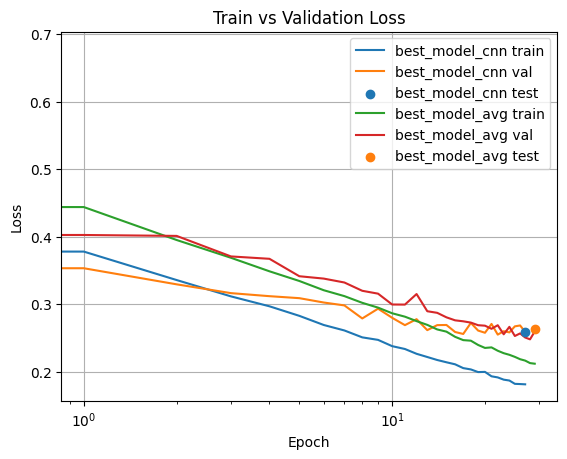

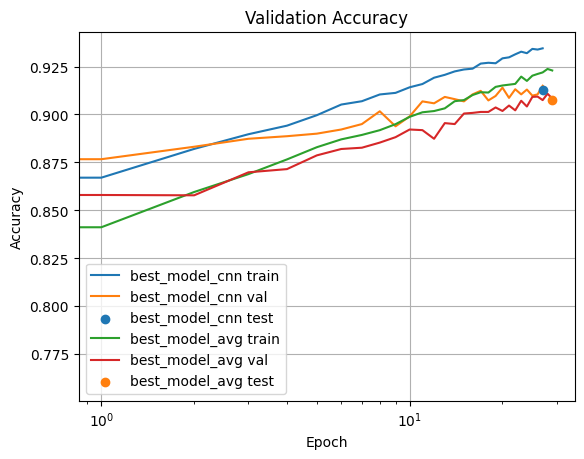

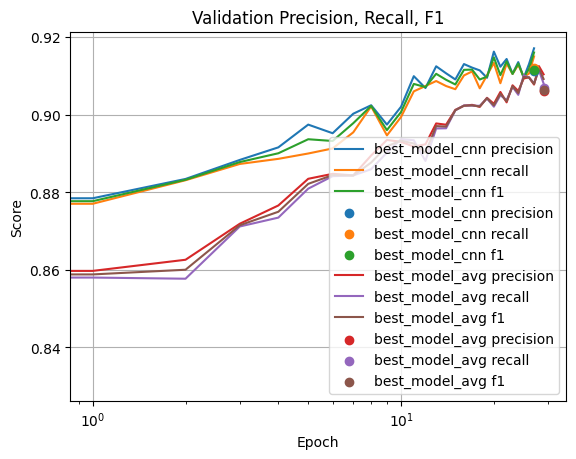

In [ ]:
df = pd.read_csv(f'{dir}/all_models_data_4.csv')
compare(df, ["best_model_cnn", "best_model_avg"])

- Bazowy model miał max pooling, eksperymentowy avg pooling.
- Max od początku lepiej sobie radził i szybciej wychwycał istotne cechy. Finalnie modele skończyły z podobnymi rezultatami, ale avg pool potrzebował na to marginalnie więcej czasu.
- Ogólnie wyniki całkiem dobre, acc powyżej 90%.
- Do kolejnych eksperymentów zdecydowałem się użyć max poola, bo szybciej wyłapywał istotne cechy.

### Eksperyment 2: Global average pooling vs flatten

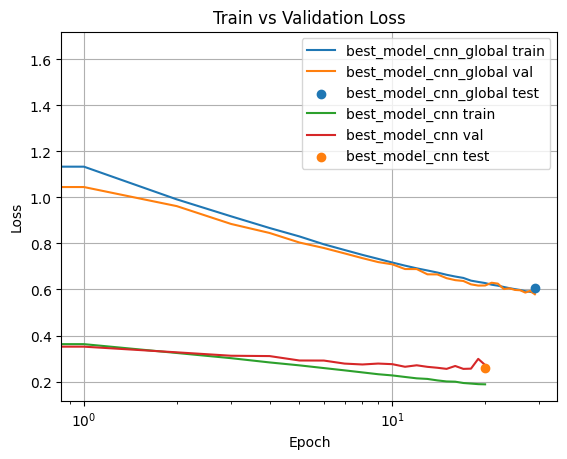

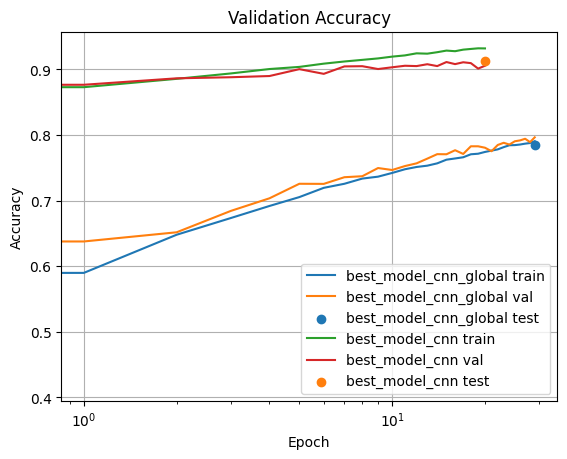

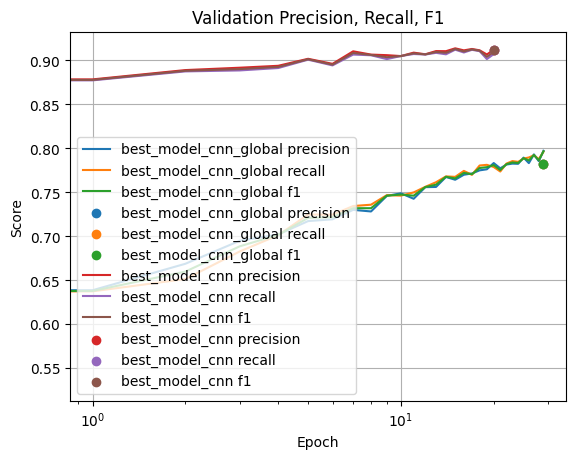

In [ ]:
df = pd.read_csv(f'{dir}/all_models_data_3.csv')
compare(df, ["best_model_cnn_global", "best_model_cnn"])

- Porównuję Global Avg Pooling z bazowym modelem, który spłaszczał konwolucje do warstw liniowych.
- Model z GAP dużo, dużo wolniej się uczył i osiągnął znacznie gorsze wyniki, pewnie dlatego że biorąc średnią z kanałów tracił istotne informacje (ale zyskując mniejszy rozmiar warstwy liniowej).
- Model z global poolingiem miał gorsze wyniki, więc nie używałem go w kolejnych eksperymentach.

### Eksperyment 3: batch normalization vs dropout

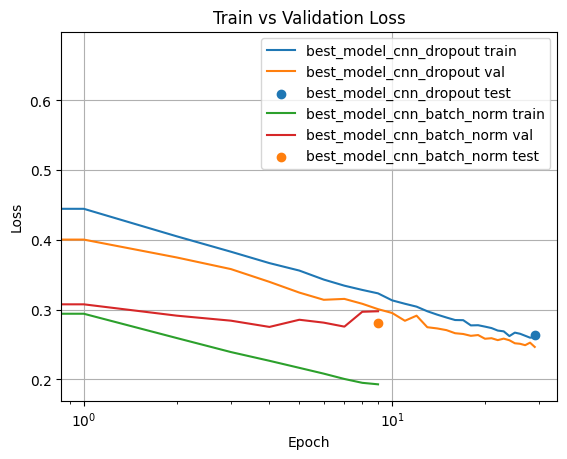

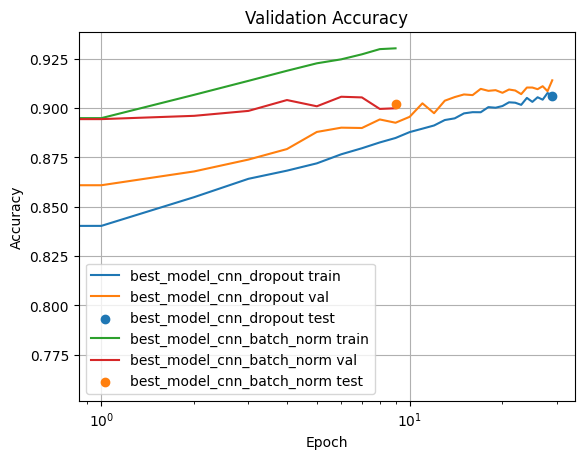

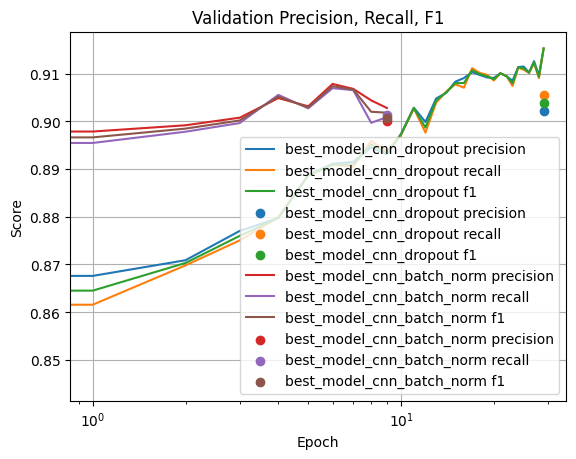

In [ ]:
compare(df, ["best_model_cnn_dropout", "best_model_cnn_batch_norm"])

- Porównuję dwa nowe modele - z batch normalization i dropout.
- Model z BN strasznie szybko się uczył i przestawał generalizować, podczas gdy modelowi z dropoutem zajmowało to znacznie dłużej.
- Za to model z dropout osiągnął lepszy wynik f1 i przy dłuższym treningu jeszcze by go poprawił.

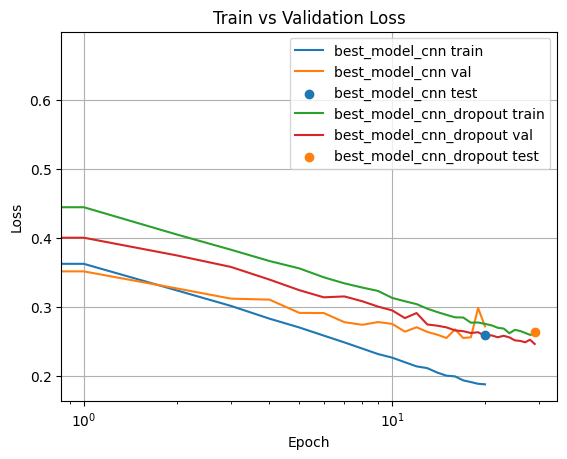

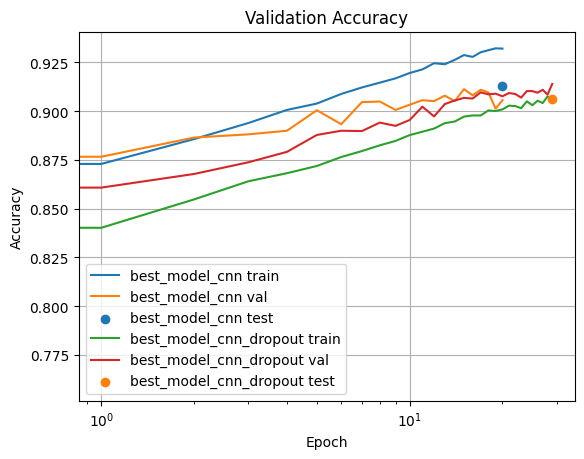

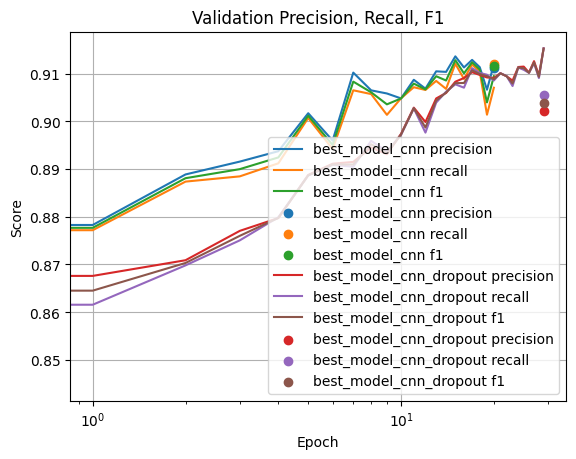

In [ ]:
compare(df, ["best_model_cnn", "best_model_cnn_dropout"])

- Porównuję lepszy z modeli - dropout - z bazowym.
- Model z dropoutem uczył się wolniej i po 30 epokach miał gorsze wyniki niż bazowy. Ale bazowy został przerwany przez patience, czyli model z dropout miałby potencjał dalej się douczyć i może prześcignąć bazowy przy większej liczbie epok.
- Do kolejnych eksperymentów nie użyłem ani BN ani dropoutu.

### Eksperyment 4: Więcej warstw konwolucyjnych

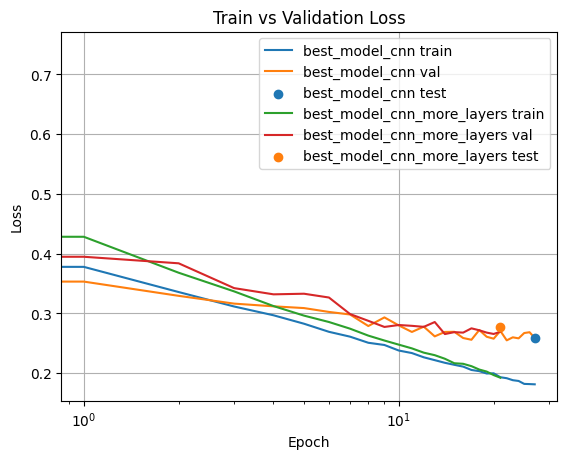

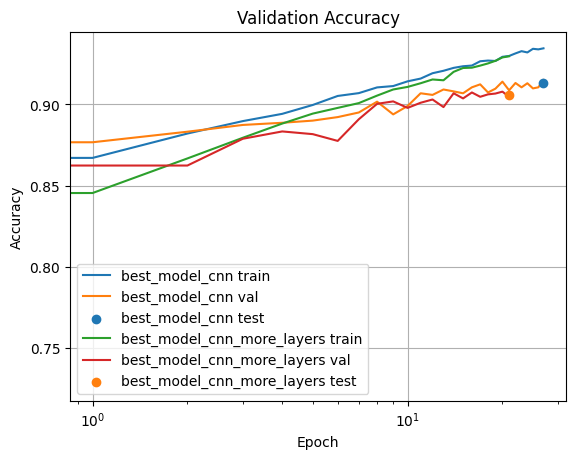

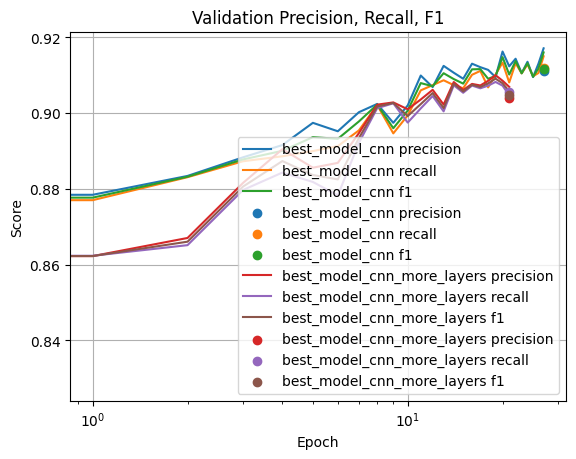

In [ ]:
df = pd.read_csv(f'{dir}/all_models_data_4.csv')
compare(df, ["best_model_cnn", "best_model_cnn_more_layers"])

- O dziwo więcej warstw wcale nie dało lepszych wyników. Model szybciej zaczynał się przeuczać. Finalnie miał gorsze f1.

### Eksperyment 5: zmiana domyślnych parametrów

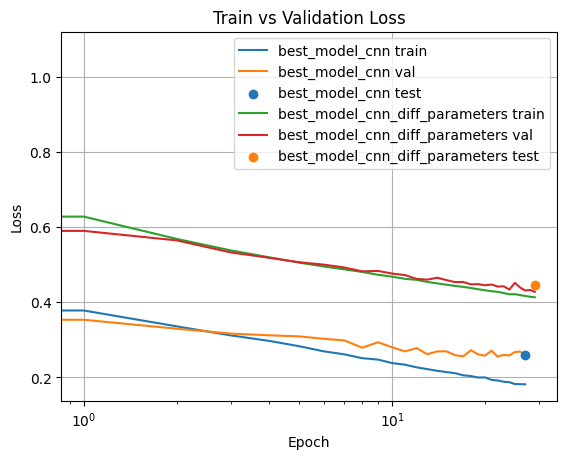

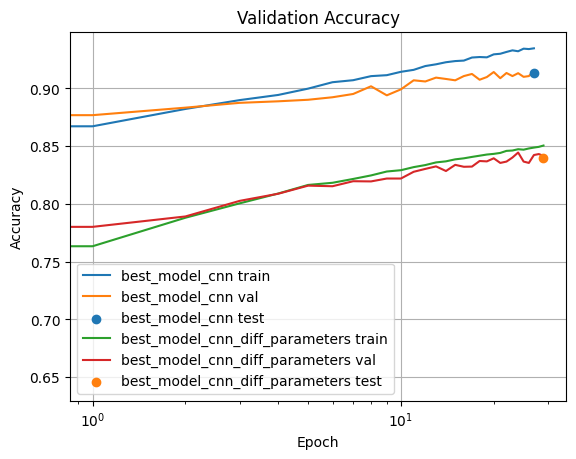

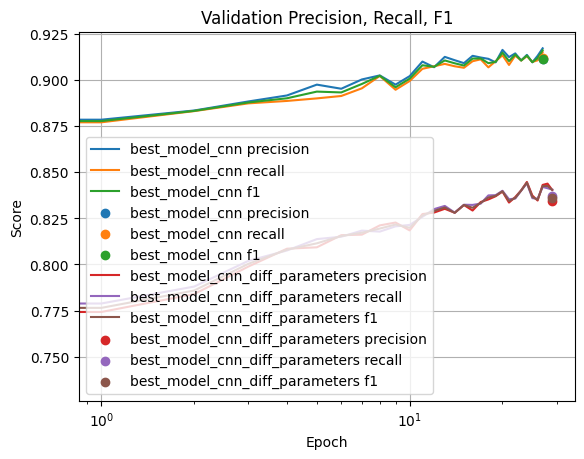

In [21]:
df = pd.read_csv(f'{dir}/all_models_data_4.csv')
df = df[df["model"] != "best_model_cnn_diff_parameters"]
df2 = pd.read_csv(f'{dir}/all_models_data_5.csv')
df2 = df2[df2["model"] != "best_model_cnn"]
df = pd.concat([df, df2])
compare(df, ["best_model_cnn", "best_model_cnn_diff_parameters"])

- Porównuję model bazowy z takim, który ma zmienione hiperparametry warstw konwolucyjnych.
- Zmiana parametrów drastycznie pogorszyła wyniki modelu. Cóż, przy takich małych obrazkach nie miało to chyba sensu. Może przy dłuższym treningu osiągnałby podobny poziom.

### Podsumowanie
- Nie wiem, czy któraś z technik nie miała przypadkiem poprawić wyników modelu. U mnie się nie udało.
- W niektórych eksperymentach regularyzacja pomogłaby się nie przeuczać i może wtedy coś by to dało. Może to też kwestia lepszego doboru hiperparametrów.
### Błędy
- Możliwe, że ustawiłem patience na za mały i modele z batch normalization za szybko przerywały uczenie.
- Na początku miałem problemy z poprawnym zapisaniem checkpointów i statystyk, żeby wszystko ładnie móc wczytać z dysku. Nie wiem czy teraz jest idealnie, ale na moje potrzeby działa.
- W eksperymencie 4 miałem podejrzane wyniki, okazało się że miałem batch_normalization na True i musiałem powtórzyć naukę.

### *Zadanie 5 (dla chętnych)

Wykorzystaj [CAM](https://zilliz.com/learn/class-activation-mapping-CAM) do wizualizacji aktywacji konwolucji dla kilku przykładów ze zbioru testowego. Do tego celu twoja sieć musi koniecznie mieć warstwę Global Avg Pooling, a końcowy moduł FNN być jednowarstwowy.

In [16]:
import numpy as np
import cv2
from torchvision import models, transforms
from torch.nn import functional as F

device = 'cpu'
ckpt = torch.load(f"{dir}/best_model_cnn_global_ckpt.pt", map_location=device)
model_cls = MODEL_CLASSES[ckpt["model_class"]]
model = model_cls(**ckpt["model_kwargs"]).to(device)
model.load_state_dict(ckpt["state_dict"])
model.eval()

activation = {}
def getActivation(name):
    # the hook signature
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

model.dropout2.register_forward_hook(getActivation('final_conv'))

In [75]:
def get_image():
  inputs, classes = random.choice(list(test_loader))
  image_tensor = inputs[0].reshape(1, 1, 28, 28)
  label = classes[0]
  image_orig = image_tensor.squeeze() * 0.5 + 0.5
  image_orig = image_orig.numpy()
  return image_orig, image_tensor

# plt.imshow(image_orig, cmap='gray')
# plt.axis('off')
# plt.show()

predicted class: 9


/tmp/ipython-input-1774/3392480463.py:12: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  class_idx = F.softmax(outputs).argmax().item()
/tmp/ipython-input-1774/3392480463.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  cam = weight_fc[class_idx].dot(feature_conv.reshape((nc, h * w)))


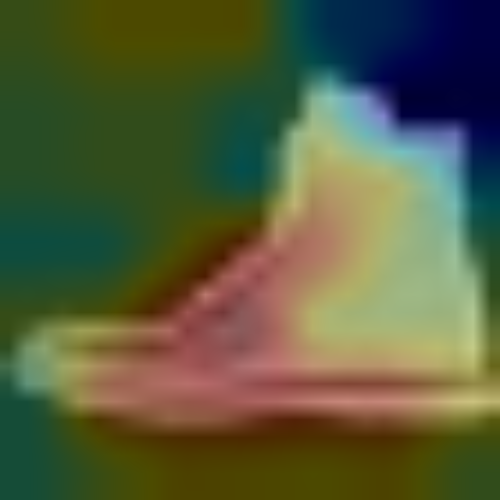

In [80]:
from google.colab.patches import cv2_imshow
image_orig, image_tensor = get_image()

outputs = model(image_tensor)
# Fetch feature maps at the final convolutional layer
conv_features = activation['final_conv']

# Fetch the learned weights at the final feed-forward layer
weight_fc = model.lin.weight.detach().numpy()

# get the idx of predicted class
class_idx = F.softmax(outputs).argmax().item()
print(f"predicted class: {class_idx}")

def calculate_cam(feature_conv, weight_fc, class_idx):
  size_upsample = (28, 28)
  bz, nc, h, w = feature_conv.shape

  cam = weight_fc[class_idx].dot(feature_conv.reshape((nc, h * w)))
  cam = cam.reshape(h, w)
  cam = cam - np.min(cam)
  cam_img = cam / np.max(cam)
  cam_img = np.uint8(255 * cam_img)

  output_cam = cv2.resize(cam_img, size_upsample)

  return output_cam

# generate class activation mapping
class_activation_map = calculate_cam(conv_features, weight_fc, class_idx)

def visualize_cam(class_activation_map, width, height, orig_image):
  orig_image = orig_image * 255
  if len(orig_image.shape) == 2:  # Grayscale
    orig_image = np.repeat(orig_image[..., np.newaxis], 3, axis=-1)

  class_activation_map_rgb = cv2.applyColorMap(class_activation_map, cv2.COLORMAP_JET)

  result = class_activation_map_rgb * 0.3 + orig_image * 0.5

  result = cv2.resize(result, (width, height))
  result = np.uint8(result)
  cv2_imshow(result)
  cv2.waitKey(0)

visualize_cam(class_activation_map, 500, 500, image_orig)